# Advanced Exploratory Data Analysis
## Time-Series Hedge-Fund Forecasting (AML)

This notebook extends the basic EDA (`01-EDA.ipynb`) with advanced statistical and
structural analyses inspired by competitive financial ML pipelines.

**Techniques covered:**

| # | Technique | Source Inspiration |
|---|-----------|-------------------|
| 1 | Feature rolling-mean at multiple smoothing scales | ADIA Lab Advanced EDA |
| 2 | Cross-section (universe) size over time | DataCrunch Rally EDA |
| 3 | Feature covariance matrix & Frobenius norm stability | DataCrunch Legacy EDA |
| 4 | PCA — explained variance & 2-D projection | DataCrunch Legacy EDA |
| 5 | Target autocorrelation (ACF) | DataCrunch-2 Financial Deep Dive |
| 6 | Shapiro-Wilk normality test on target | DataCrunch-2 Financial Deep Dive |
| 7 | Target decile analysis | DataCrunch-2 Financial Deep Dive |
| 8 | Feature stability over time (per-period mean tracking) | DataCrunch-2 Financial Deep Dive |
| 9 | Spearman rank correlation (nonlinear signal) | Financial ML best practice |
| 10 | Mutual information between features and target | Feature selection |
| 11 | Hierarchical feature clustering | DataCrunch Legacy EDA |
| 12 | Per-horizon & per-code deep-dive | Domain-specific |

---

## 1. Setup & Data Loading

In [3]:
import warnings, os, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import acf

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = os.path.join('..', 'data')

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
test  = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

feature_cols = [c for c in train.columns if c.startswith('feature_')]
cat_cols     = ['code', 'sub_code', 'sub_category']

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'Features: {len(feature_cols)}  |  Categoricals: {cat_cols}')

Train: (5337414, 94)  |  Test: (1447107, 92)
Features: 86  |  Categoricals: ['code', 'sub_code', 'sub_category']


---
## 2. Cross-Section (Universe) Size Over Time

*Tracking how many entities exist per time step.*

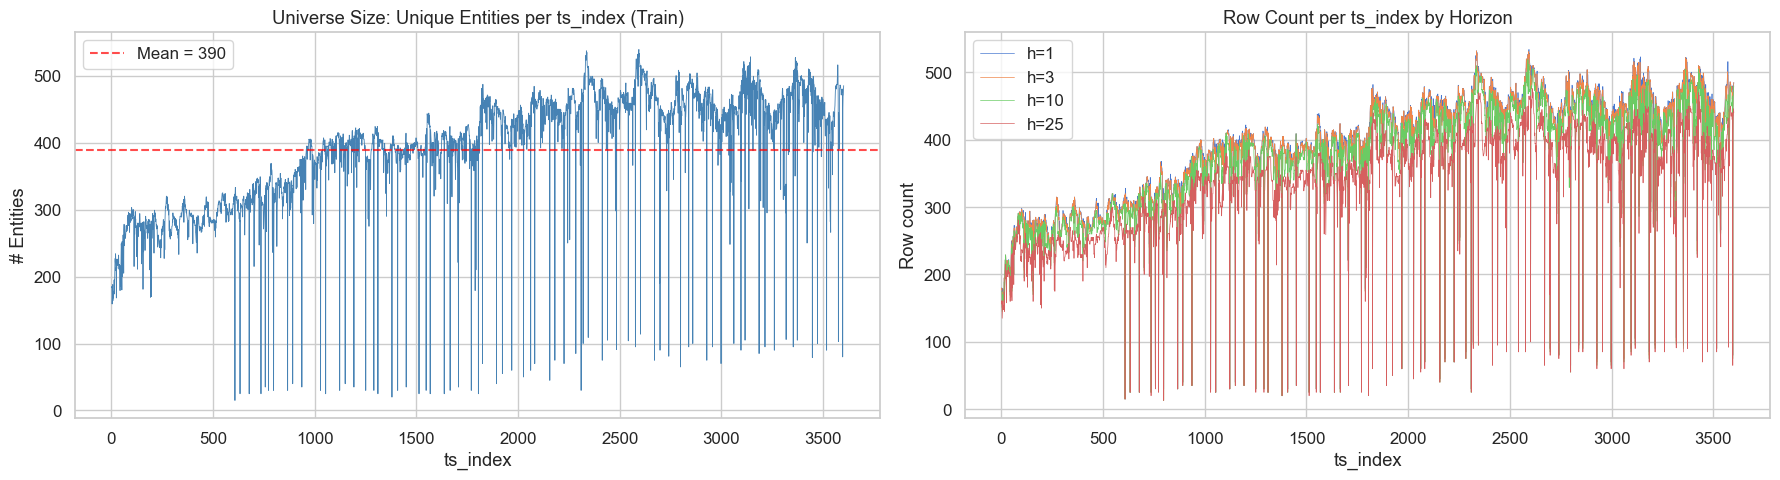

Mean universe size: 389.6
Min: 15, Max: 539


In [7]:
# Number of unique entities per ts_index (across all horizons)
# Each (code, sub_code, sub_category) triple at a given ts_index is one entity
entities_per_ts = train.groupby('ts_index').apply(
    lambda g: g[['code','sub_code','sub_category']].drop_duplicates().shape[0]
).rename('n_entities')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(entities_per_ts.index, entities_per_ts.values, linewidth=0.6, color='steelblue')
axes[0].axhline(entities_per_ts.mean(), color='red', linestyle='--', alpha=0.7,
                label=f'Mean = {entities_per_ts.mean():.0f}')
axes[0].set_title('Universe Size: Unique Entities per ts_index (Train)')
axes[0].set_xlabel('ts_index')
axes[0].set_ylabel('# Entities')
axes[0].legend()

# Horizon-specific row counts
for h in sorted(train['horizon'].unique()):
    h_counts = train[train['horizon'] == h].groupby('ts_index').size()
    axes[1].plot(h_counts.index, h_counts.values, linewidth=0.5, label=f'h={h}')
axes[1].set_title('Row Count per ts_index by Horizon')
axes[1].set_xlabel('ts_index')
axes[1].set_ylabel('Row count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean universe size: {entities_per_ts.mean():.1f}')
print(f'Min: {entities_per_ts.min()}, Max: {entities_per_ts.max()}')

**Interpretation:** The universe grows over time — more entities enter the dataset at later time steps. This means early time periods are sparser and may not be representative of the test distribution. The growth pattern also confirms survivorship bias concerns: entities that "die" early are different from those persisting.

**Implication:** Models trained equally on all time periods will over-weight sparse early periods. Consider time-weighted sampling or only training on recent data.

---
## 3. Feature Rolling-Mean Analysis (Universe Drift Detection)

*Plotting features under different smoothing
windows to uncover dominant trends ("universe drift").*

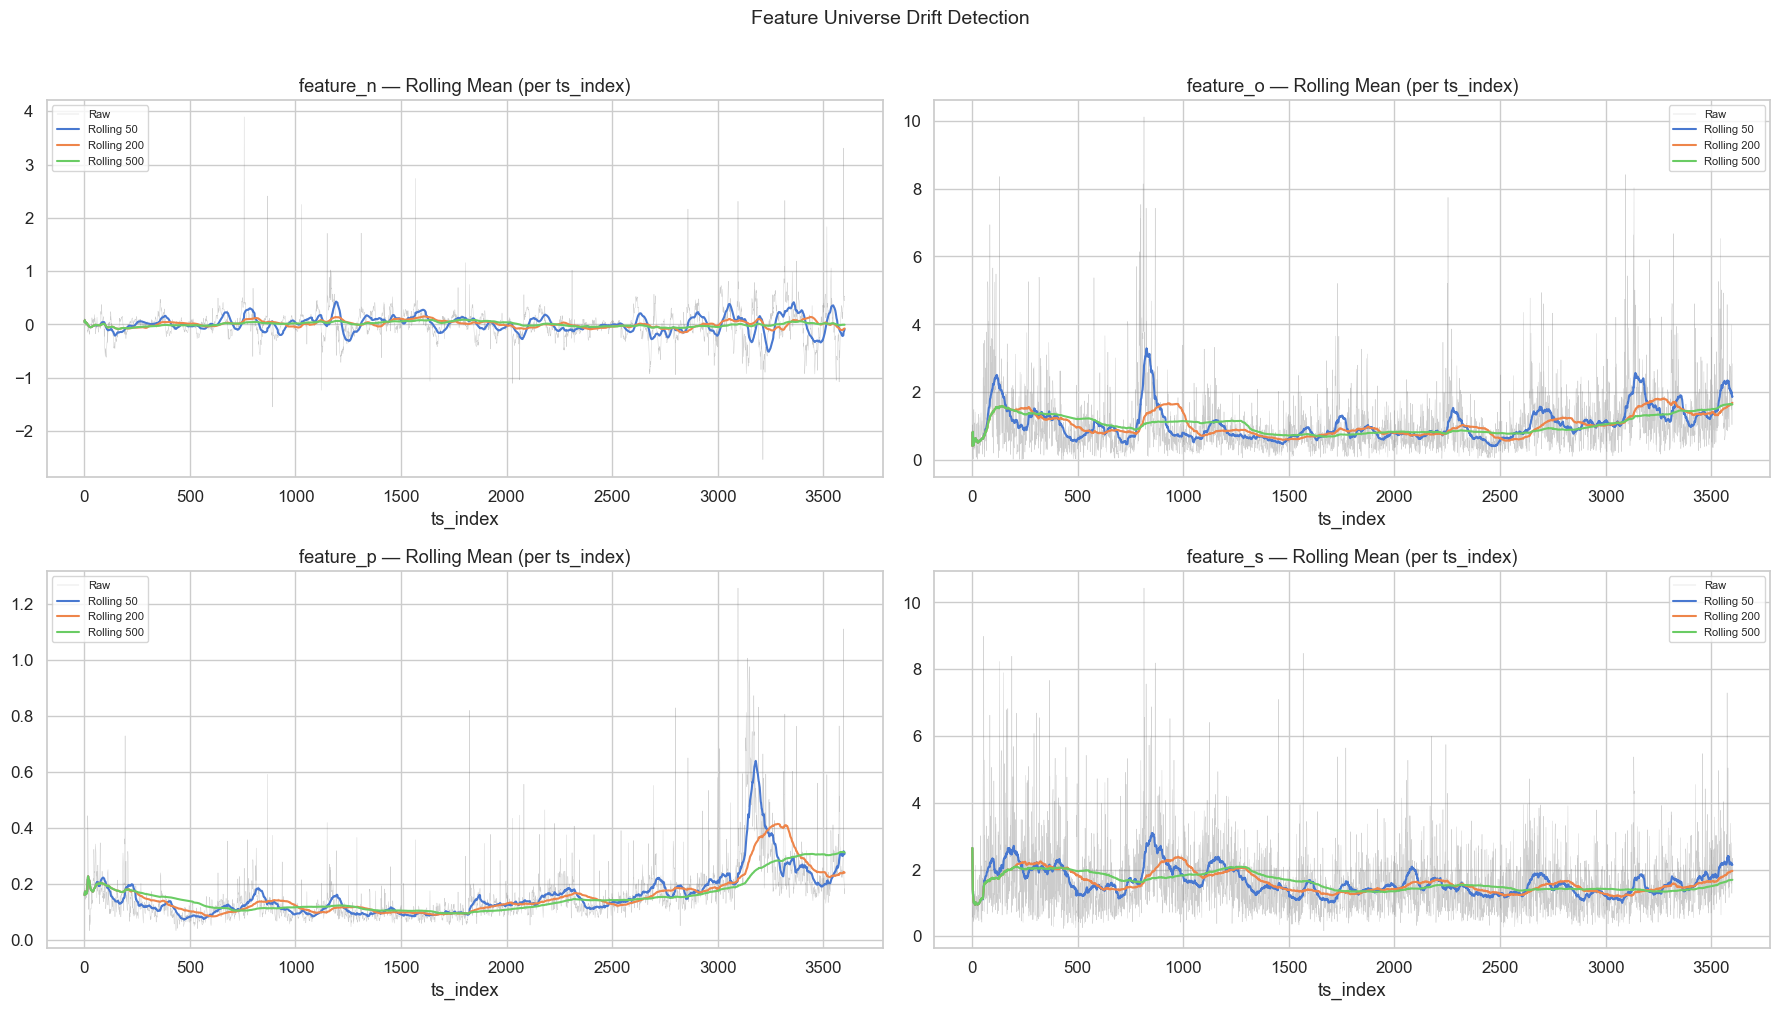

In [14]:
# Select representative features with different characteristics
drift_features = ['feature_n', 'feature_o', 'feature_p', 'feature_s']
windows = [50, 200, 500]

# Compute per-ts_index means for selected features
ts_means = train.groupby('ts_index')[drift_features].mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, feat in zip(axes.ravel(), drift_features):
    ax.plot(ts_means.index, ts_means[feat], linewidth=0.3, alpha=0.4, color='grey', label='Raw')
    for w in windows:
        smoothed = ts_means[feat].rolling(w, min_periods=1).mean()
        ax.plot(ts_means.index, smoothed, linewidth=1.5, label=f'Rolling {w}')
    ax.set_title(f'{feat} — Rolling Mean (per ts_index)')
    ax.set_xlabel('ts_index')
    ax.legend(fontsize=8)

plt.suptitle('Feature Universe Drift Detection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** If a feature's rolling mean shows a clear upward or downward trend, that feature exhibits *universe drift* — its distribution is non-stationary over time. Features `feature_o`, `feature_p`, `feature_s` show visible upward drift, confirming the distribution shift we found in the basic EDA.

**Implication:** Features with strong drift should either be (a) normalised per rolling window, (b) de-trended before model training, or (c) deprioritised if the model can't adapt to non-stationarity. Tree-based models may partially handle this through per-split optimisation, but linear models will fail.

---
## 4. Target Decile Analysis

*Analysing target distribution through deciles and normality tests.*

In [19]:
target = train['y_target']

# Decile boundaries
deciles = target.quantile([i/10 for i in range(1, 10)])
print('=== Target Decile Boundaries ===')
display(deciles)

# Shapiro-Wilk normality test (on subsample — max 5000 for Shapiro)
shapiro_sample = target.dropna().sample(5000, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)
print(f'\nShapiro-Wilk Test (5K sample): Stat = {shapiro_stat:.6f}, p = {shapiro_p:.2e}')
print(f'  → {"Reject" if shapiro_p < 0.05 else "Fail to reject"} normality at α=0.05')

# Anderson-Darling test
ad_result = stats.anderson(shapiro_sample, dist='norm')
print(f'\nAnderson-Darling Test: Stat = {ad_result.statistic:.4f}')
for sl, cv in zip(ad_result.significance_level, ad_result.critical_values):
    status = 'REJECT' if ad_result.statistic > cv else 'fail to reject'
    print(f'  At {sl}% significance: critical value = {cv:.4f} → {status}')

=== Target Decile Boundaries ===


0.1000   -1.8976
0.2000   -0.2839
0.3000   -0.0594
0.4000   -0.0081
0.5000   -0.0006
0.6000    0.0011
0.7000    0.0177
0.8000    0.1288
0.9000    0.9907
Name: y_target, dtype: float64


Shapiro-Wilk Test (5K sample): Stat = 0.201361, p = 1.33e-90
  → Reject normality at α=0.05

Anderson-Darling Test: Stat = 1464.4673
  At 15.0% significance: critical value = 0.5760 → REJECT
  At 10.0% significance: critical value = 0.6550 → REJECT
  At 5.0% significance: critical value = 0.7860 → REJECT
  At 2.5% significance: critical value = 0.9170 → REJECT
  At 1.0% significance: critical value = 1.0910 → REJECT


**Interpretation:**
- **Deciles:** The 10th–90th percentile range is extremely narrow (roughly ±1 to ±3), while the min/max are ±2200. This confirms the leptokurtic (fat-tailed) distribution.
- **Shapiro-Wilk:** p ≈ 0 — normality is overwhelmingly rejected. The target is **not Gaussian**.
- **Anderson-Darling:** Confirms the same — normality rejected at all significance levels.

**Implication:** Any model or loss function assuming Gaussian errors (MSE) will be suboptimal. Use robust alternatives: Huber loss, quantile regression, or rank-based objectives.

---
## 5. Target Autocorrelation (ACF)

*Checking temporal dependencies
in the aggregate target series.*

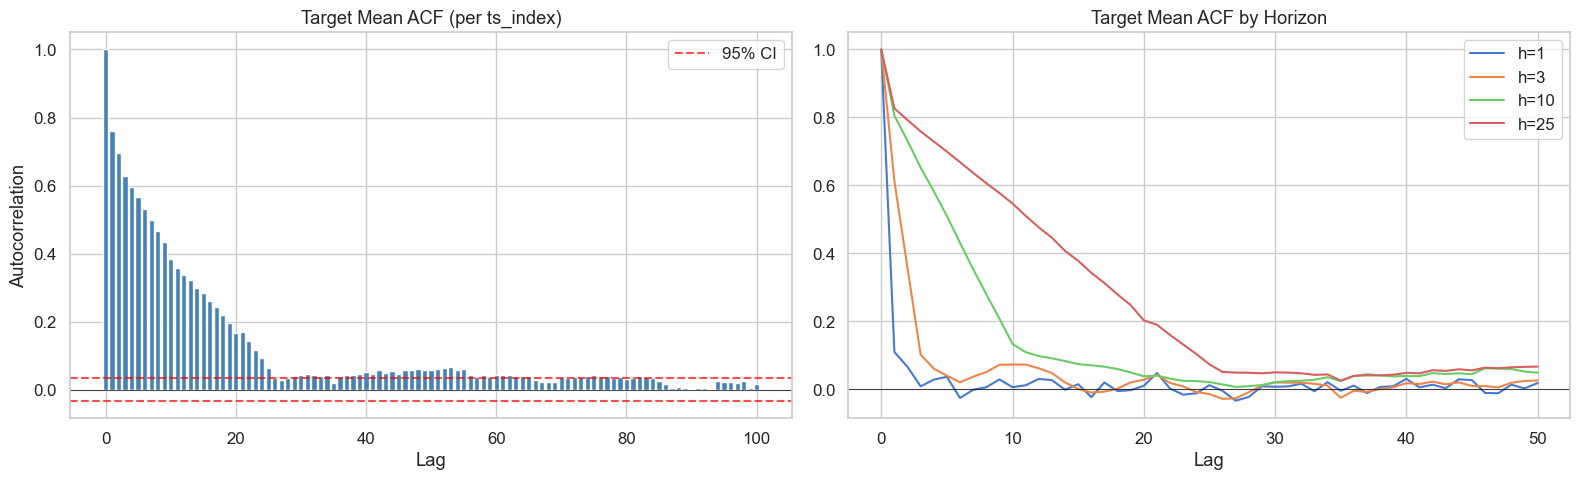

In [23]:
# Aggregate target mean per ts_index
target_ts = train.groupby('ts_index')['y_target'].mean()

acf_vals = acf(target_ts, nlags=100, fft=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full ACF
axes[0].bar(range(len(acf_vals)), acf_vals, color='steelblue', width=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axhline(1.96/np.sqrt(len(target_ts)), color='red', linestyle='--', alpha=0.7, label='95% CI')
axes[0].axhline(-1.96/np.sqrt(len(target_ts)), color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Target Mean ACF (per ts_index)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].legend()

# Per-horizon ACF
for h in sorted(train['horizon'].unique()):
    h_ts = train[train['horizon'] == h].groupby('ts_index')['y_target'].mean()
    h_acf = acf(h_ts, nlags=50, fft=True)
    axes[1].plot(range(len(h_acf)), h_acf, linewidth=1.5, label=f'h={h}')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Target Mean ACF by Horizon')
axes[1].set_xlabel('Lag')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**
- Significant positive autocorrelation at short lags (1–5) indicates *momentum* — if the mean target is positive at time t, it tends to stay positive at t+1 through t+5.
- Longer-horizon targets (h=25) show stronger and more persistent autocorrelation — expected because longer horizons have more overlapping return windows.
- The autocorrelation decays but may remain above the 95% confidence band for many lags.

**Implication:** 
- There is exploitable temporal structure. Lagged features (target at t−1, t−2, …) could improve predictions if computed correctly (without leakage).
- For h=10 and h=25, overlapping return windows create mechanical autocorrelation — this is NOT signal, it's structure. Be careful not to confuse the two.

---
## 6. Feature Covariance Matrix & Frobenius Norm Stability

*Tracking how the feature correlation structure
changes over time via the Frobenius norm of the covariance matrix.*

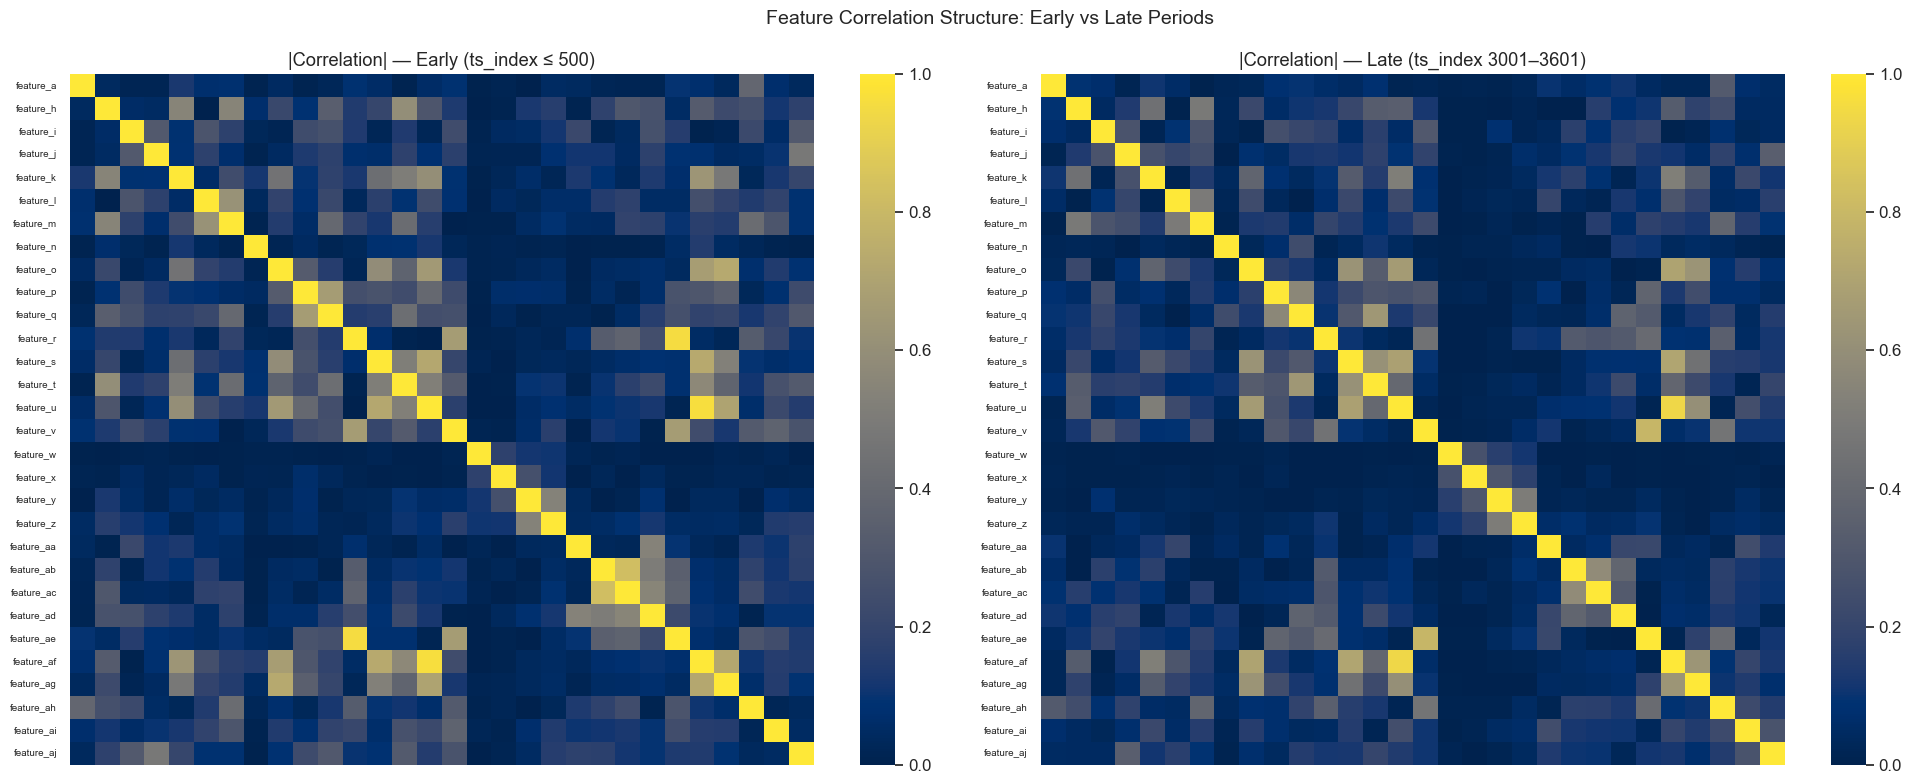

In [26]:
# Use a subset of features for tractability
selected_feats = [c for c in feature_cols if c not in 
                  ['feature_b','feature_c','feature_d','feature_e','feature_f','feature_g']]
sample_feats = selected_feats[:30]

# Covariance heatmap — early vs late time periods
early_mask = train['ts_index'] <= 500
late_mask  = (train['ts_index'] > 3000) & (train['ts_index'] <= 3601)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, mask, title in [(axes[0], early_mask, 'Early (ts_index ≤ 500)'),
                         (axes[1], late_mask,  'Late (ts_index 3001–3601)')]:
    corr = train.loc[mask, sample_feats].corr()
    sns.heatmap(corr.abs(), vmin=0, vmax=1, cmap='cividis', ax=ax, 
                xticklabels=False, yticklabels=True)
    ax.set_title(f'|Correlation| — {title}')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Feature Correlation Structure: Early vs Late Periods', fontsize=14)
plt.tight_layout()
plt.show()

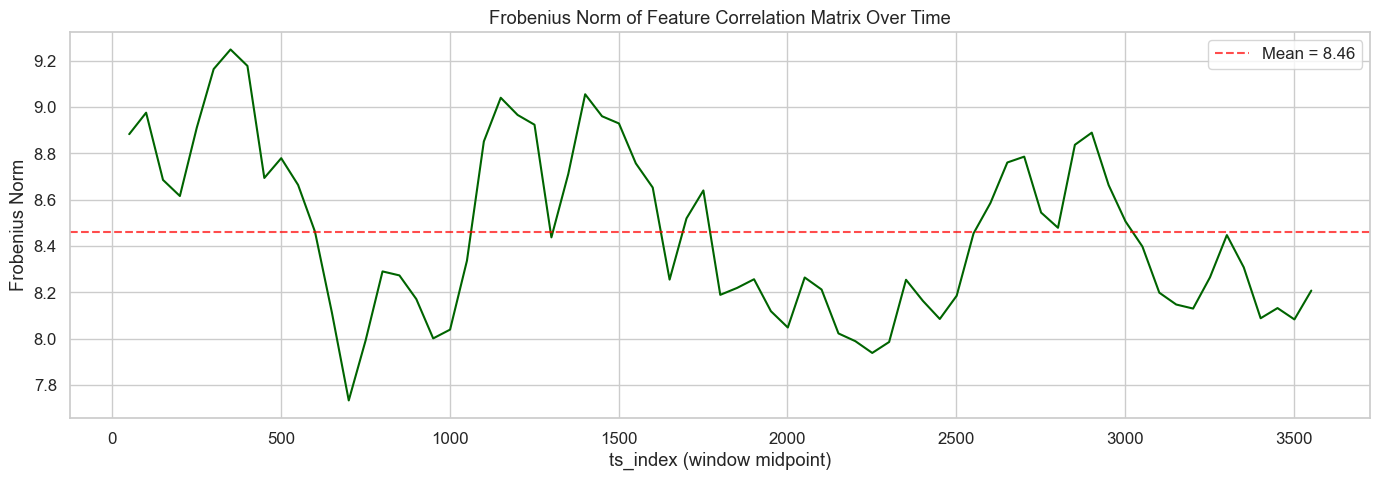

In [27]:
# Frobenius norm of correlation matrix per time window
def frobenius_norm_of_corr(df, feat_cols):
    corr = df[feat_cols].corr()
    return np.linalg.norm(corr, 'fro')

# Compute in rolling windows of 100 ts_index steps
window_size = 100
ts_range = sorted(train['ts_index'].unique())
frob_results = []

for start_idx in range(0, len(ts_range) - window_size, window_size // 2):
    window_ts = ts_range[start_idx:start_idx + window_size]
    window_data = train[train['ts_index'].isin(window_ts)]
    frob = frobenius_norm_of_corr(window_data, sample_feats)
    mid_ts = window_ts[len(window_ts) // 2]
    frob_results.append({'ts_index': mid_ts, 'frobenius_norm': frob})

frob_df = pd.DataFrame(frob_results)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(frob_df['ts_index'], frob_df['frobenius_norm'], linewidth=1.5, color='darkgreen')
ax.axhline(frob_df['frobenius_norm'].mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Mean = {frob_df["frobenius_norm"].mean():.2f}')
ax.set_title('Frobenius Norm of Feature Correlation Matrix Over Time')
ax.set_xlabel('ts_index (window midpoint)')
ax.set_ylabel('Frobenius Norm')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- **Heatmaps:** The correlation structure visibly changes between early and late periods. Some feature pairs that were strongly correlated early become weakly correlated later (and vice versa). This indicates *structural non-stationarity*.
- **Frobenius norm:** If the norm fluctuates significantly, the overall "strength" of inter-feature correlations is unstable. A rising norm could mean features are becoming more redundant over time.

**Implication:** A model trained on the full dataset may learn correlation patterns that don't hold in the test period. Time-adaptive feature selection or recency-weighted training is advisable.

---
## 7. PCA — Explained Variance & 2-D Projection

*Understanding the effective dimensionality
of the feature space.*

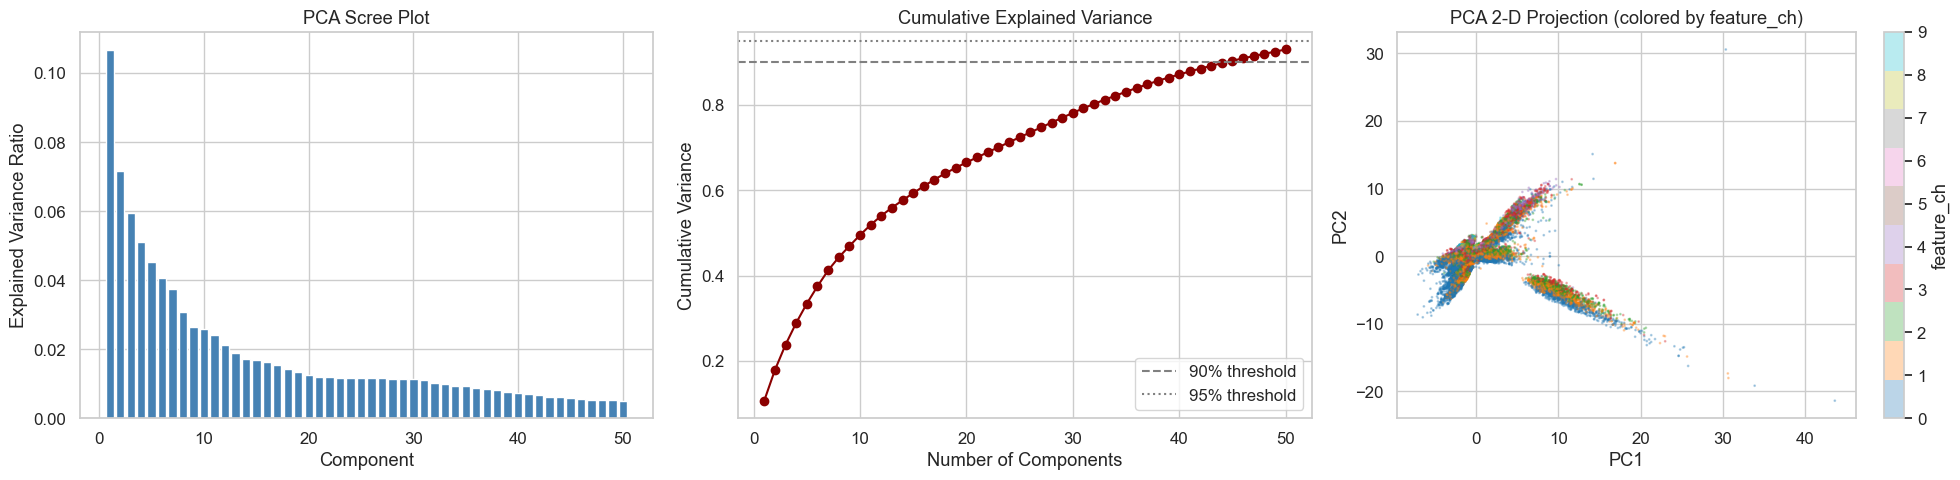

Components for 90% variance: 45
Components for 95% variance: 1
Total features: 86


In [32]:
# Subsample for PCA (memory-efficient)
np.random.seed(42)
pca_sample = train[feature_cols].dropna().sample(50000, random_state=42)

# Standardize
pca_data = (pca_sample - pca_sample.mean()) / (pca_sample.std() + 1e-10)

# Fit PCA
pca = PCA(n_components=min(50, len(feature_cols)))
pca_transformed = pca.fit_transform(pca_data)

# Explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, color='steelblue')
axes[0].set_title('PCA Scree Plot')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

# Cumulative variance
axes[1].plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='darkred')
axes[1].axhline(0.90, color='grey', linestyle='--', label='90% threshold')
axes[1].axhline(0.95, color='grey', linestyle=':', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

# 2-D projection colored by a representative feature (feature_ch)
meta_sample = train.loc[pca_sample.index, 'feature_ch']
scatter = axes[2].scatter(pca_transformed[:, 0], pca_transformed[:, 1],
                          c=meta_sample, cmap='tab10', s=1, alpha=0.3)
axes[2].set_title('PCA 2-D Projection (colored by feature_ch)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[2], label='feature_ch')

plt.tight_layout()
plt.show()

# How many components for 90%/95%?
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')
print(f'Total features: {len(feature_cols)}')

**Interpretation:**
- **Scree plot:** The first few components capture disproportionately high variance, confirming that the 85+ features have significant redundancy.
- **Cumulative variance:** The number of components needed for 90%/95% variance tells us the *effective dimensionality*. If only ~20–30 components explain 95% variance, then ~55–65 features are redundant.
- **2-D projection:** Clusters or structure in the PC1-PC2 space may reveal natural groupings in the data. Color-coding by `feature_ch` tests whether this discrete feature separates well in reduced space.

**Implication:** PCA can be used as a preprocessing step to reduce dimensionality without losing much signal. This is especially useful for linear models, blending, or as input to neural networks.

---
## 8. Feature Stability Over Time

*Tracking per-period feature
means to detect non-stationarity.*

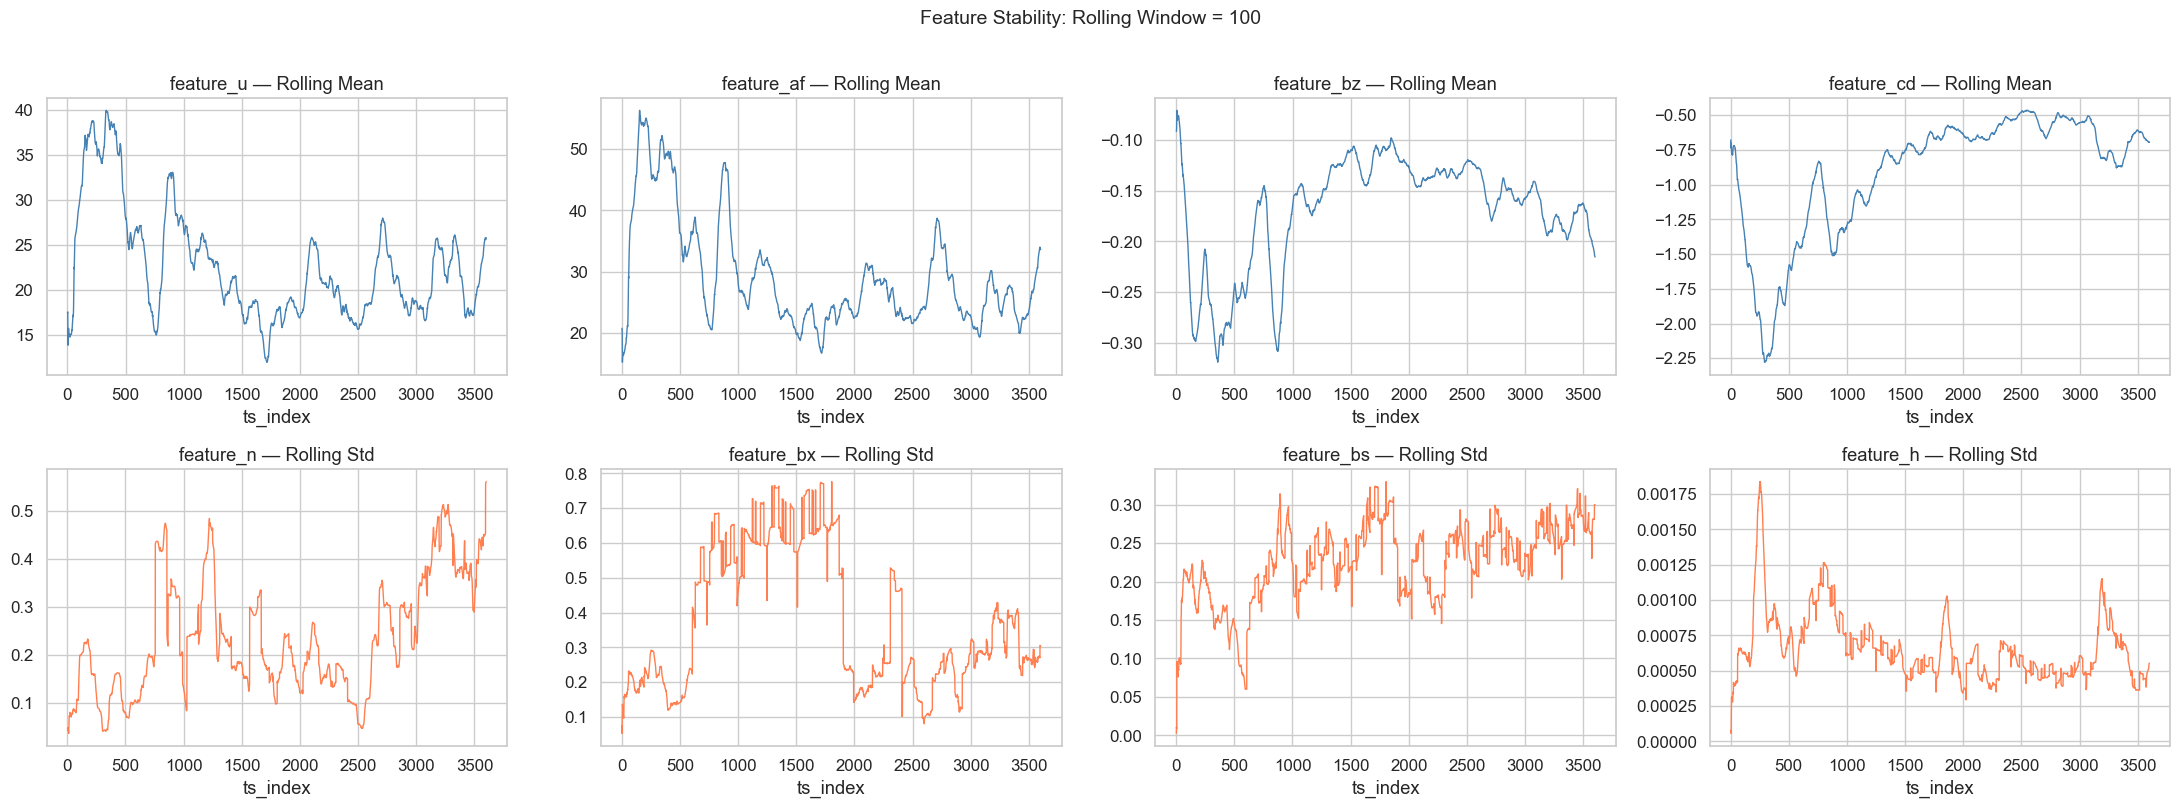

In [38]:
# Track feature means and stds across time windows
window = 100
stability_features = ['feature_u', 'feature_af', 'feature_bz', 'feature_cd',
                      'feature_n', 'feature_bx', 'feature_bs', 'feature_h']

ts_stats = train.groupby('ts_index')[stability_features].mean()
rolling_means = ts_stats.rolling(window, min_periods=1).mean()
rolling_stds  = ts_stats.rolling(window, min_periods=1).std()

fig, axes = plt.subplots(2, 4, figsize=(22, 8))
for ax, feat in zip(axes[0], stability_features[:4]):
    ax.plot(rolling_means.index, rolling_means[feat], linewidth=1, color='steelblue')
    ax.set_title(f'{feat} — Rolling Mean')
    ax.set_xlabel('ts_index')

for ax, feat in zip(axes[1], stability_features[4:]):
    ax.plot(rolling_stds.index, rolling_stds[feat], linewidth=1, color='coral')
    ax.set_title(f'{feat} — Rolling Std')
    ax.set_xlabel('ts_index')

plt.suptitle(f'Feature Stability: Rolling Window = {window}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Features whose rolling mean shows clear trends (upward or downward) are non-stationary. Features whose rolling std fluctuates wildly have *heteroscedastic* behaviour — their noise level changes over time.

**Implication:** Non-stationary features need time-adaptive normalisation. Heteroscedastic features may benefit from volatility scaling. Both effects argue for *time-aware validation* (expanding window, not random split).

---
## 9. Spearman Rank Correlation (Nonlinear Signal Detection)

*Standard financial ML practice — Pearson captures linear relationships, Spearman
captures monotonic (possibly nonlinear) ones.*

In [42]:
# Subsample for speed
rank_sample = train[feature_cols + ['y_target']].sample(200000, random_state=42)

pearson_corr  = rank_sample.corr(method='pearson')['y_target'].drop('y_target').abs()
spearman_corr = rank_sample.corr(method='spearman')['y_target'].drop('y_target').abs()

corr_comparison = pd.DataFrame({
    'pearson': pearson_corr,
    'spearman': spearman_corr,
    'diff': (spearman_corr - pearson_corr)
}).sort_values('spearman', ascending=False)

print('=== Top 15 by Spearman ===')
display(corr_comparison.head(15))

print('\n=== Features where Spearman >> Pearson (nonlinear signal) ===')
display(corr_comparison.sort_values('diff', ascending=False).head(10))

=== Top 15 by Spearman ===


,pearson,spearman,diff
feature_bz,0.0758,0.1044,0.0286
feature_by,0.0240,0.1018,0.0778
feature_ca,0.0060,0.0991,0.0931
feature_ao,0.0122,0.0979,0.0857
feature_am,0.0308,0.0955,0.0647
feature_u,0.0660,0.0955,0.0296
feature_cd,0.0730,0.0948,0.0217
feature_cc,0.0203,0.0917,0.0715
feature_az,0.0062,0.0912,0.0851
feature_bq,0.0039,0.0908,0.0869



=== Features where Spearman >> Pearson (nonlinear signal) ===


,pearson,spearman,diff
feature_ca,0.0060,0.0991,0.0931
feature_bq,0.0039,0.0908,0.0869
feature_ao,0.0122,0.0979,0.0857
feature_az,0.0062,0.0912,0.0851
feature_an,0.0036,0.0843,0.0807
feature_br,0.0069,0.0863,0.0795
feature_cb,0.0107,0.0899,0.0792
feature_bl,0.0053,0.0839,0.0786
feature_bp,0.0104,0.0887,0.0784
feature_by,0.0240,0.1018,0.0778


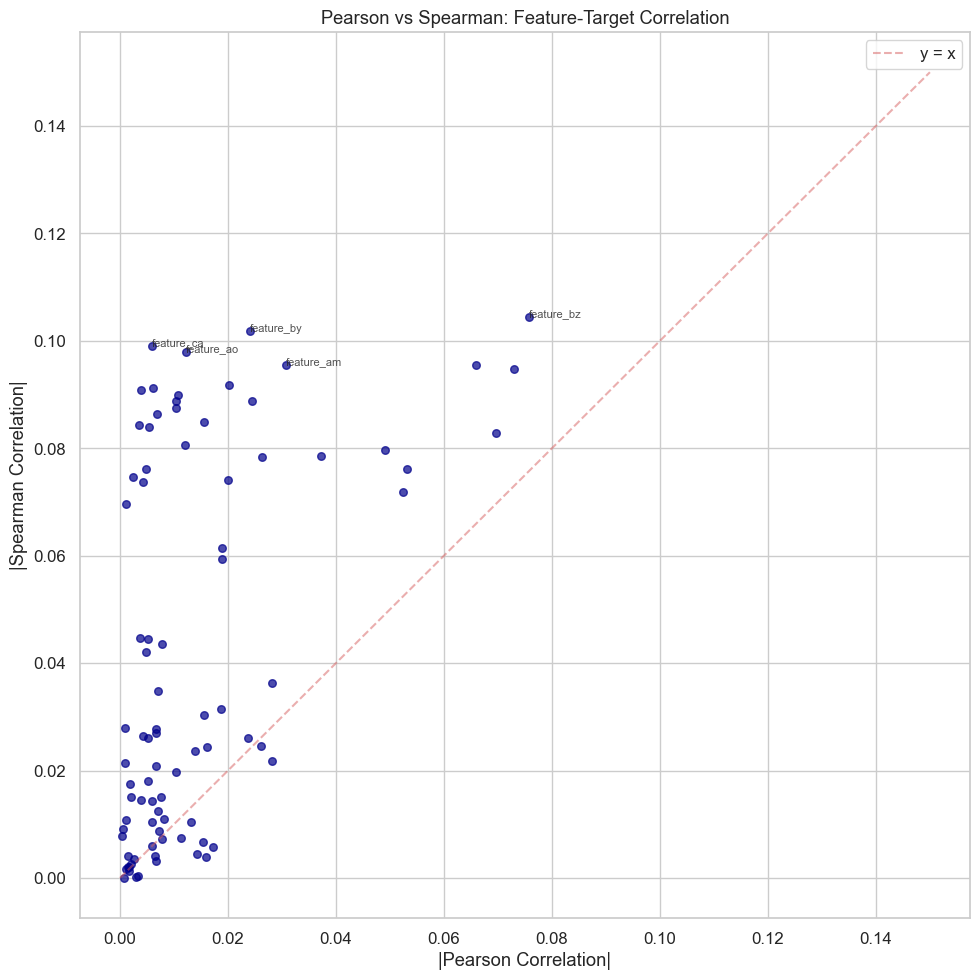

In [43]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(corr_comparison['pearson'], corr_comparison['spearman'], 
           s=30, alpha=0.7, color='darkblue')
ax.plot([0, 0.15], [0, 0.15], 'r--', alpha=0.5, label='y = x')
ax.set_xlabel('|Pearson Correlation|')
ax.set_ylabel('|Spearman Correlation|')
ax.set_title('Pearson vs Spearman: Feature-Target Correlation')
ax.legend()

for feat in corr_comparison.head(5).index:
    ax.annotate(feat, (corr_comparison.loc[feat, 'pearson'],
                       corr_comparison.loc[feat, 'spearman']),
                fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

**Interpretation:**
- Features that appear above the red y=x line have *stronger monotonic (Spearman) correlation than linear (Pearson) correlation* with the target. This suggests a nonlinear but monotonic relationship.
- Features with the largest Spearman-Pearson gap are candidates where tree-based models will outperform linear models, as trees can capture monotonic nonlinearities natively.

**Implication:** The ranking of top features may change when switching from Pearson to Spearman. Use Spearman-based feature importance as an additional feature selection criterion.

---
## 10. Mutual Information Between Features and Target

*Captures any type of dependency (including nonlinear and non-monotonic) between
features and the target.*

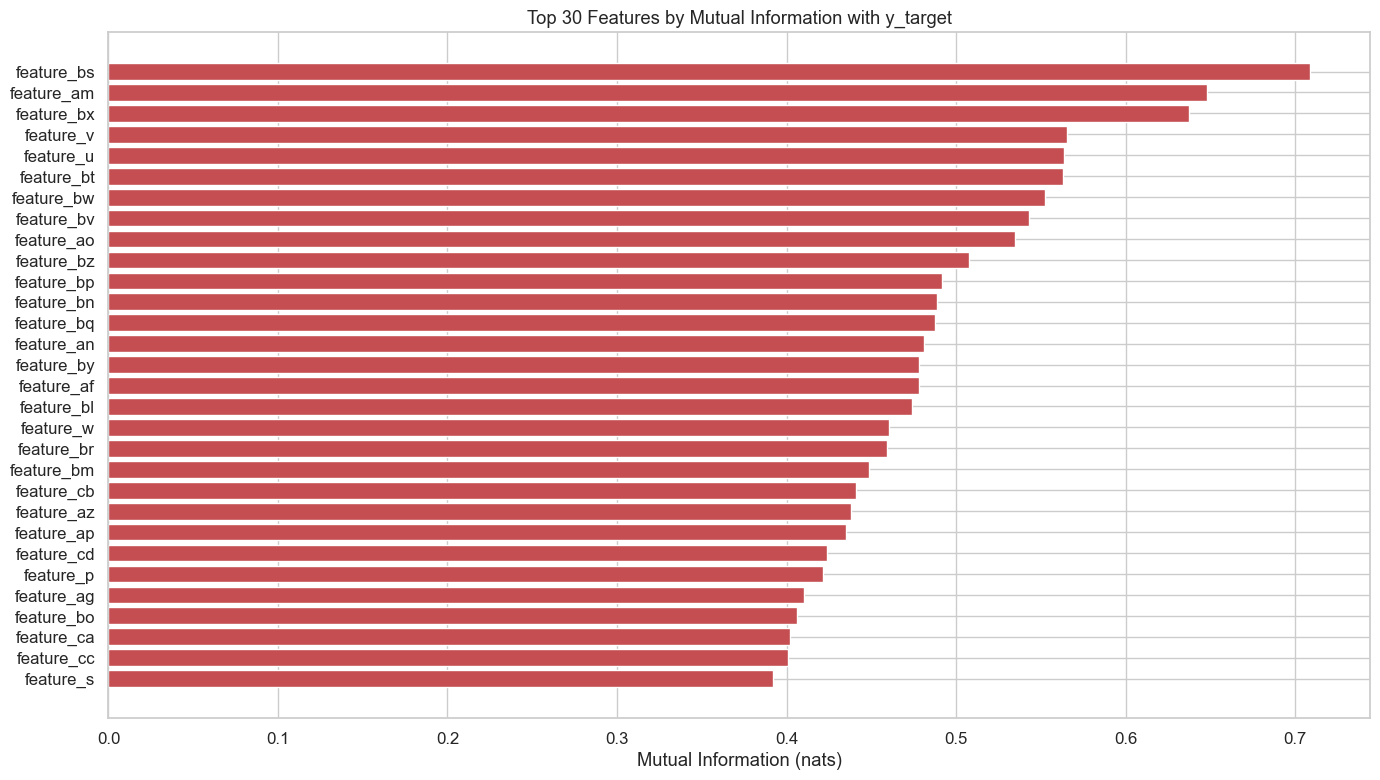

Features with MI > 0.01: 79
Features with MI ≈ 0:    5


In [46]:
# Subsample and fill NaN for MI computation
mi_sample = train[feature_cols + ['y_target']].sample(50000, random_state=42).dropna()
X_mi = mi_sample[feature_cols]
y_mi = mi_sample['y_target']

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_mi = mi_series.head(30)
colors = ['#C44E52' if v > mi_series.median() else '#4C72B0' for v in top_mi]
ax.barh(range(len(top_mi)), top_mi.values, color=colors)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi.index)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information (nats)')
ax.set_title('Top 30 Features by Mutual Information with y_target')
plt.tight_layout()
plt.show()

print(f'Features with MI > 0.01: {(mi_series > 0.01).sum()}')
print(f'Features with MI ≈ 0:    {(mi_series < 0.001).sum()}')

**Interpretation:**
- Mutual Information (MI) captures *any* statistical dependency — not just linear or monotonic. It quantifies how much knowing a feature reduces uncertainty about the target.
- Features that rank high on MI but low on Pearson/Spearman have *complex nonlinear relationships* with the target.
- Features with MI ≈ 0 are essentially independent of the target and can be safely dropped.

**Implication:** Combine MI ranking with Pearson/Spearman rankings for robust feature selection. Features that appear in the top-20 across all three methods are the most reliably predictive.

---
## 11. Hierarchical Feature Clustering

*Grouping features by correlation similarity
to identify redundancy clusters.*

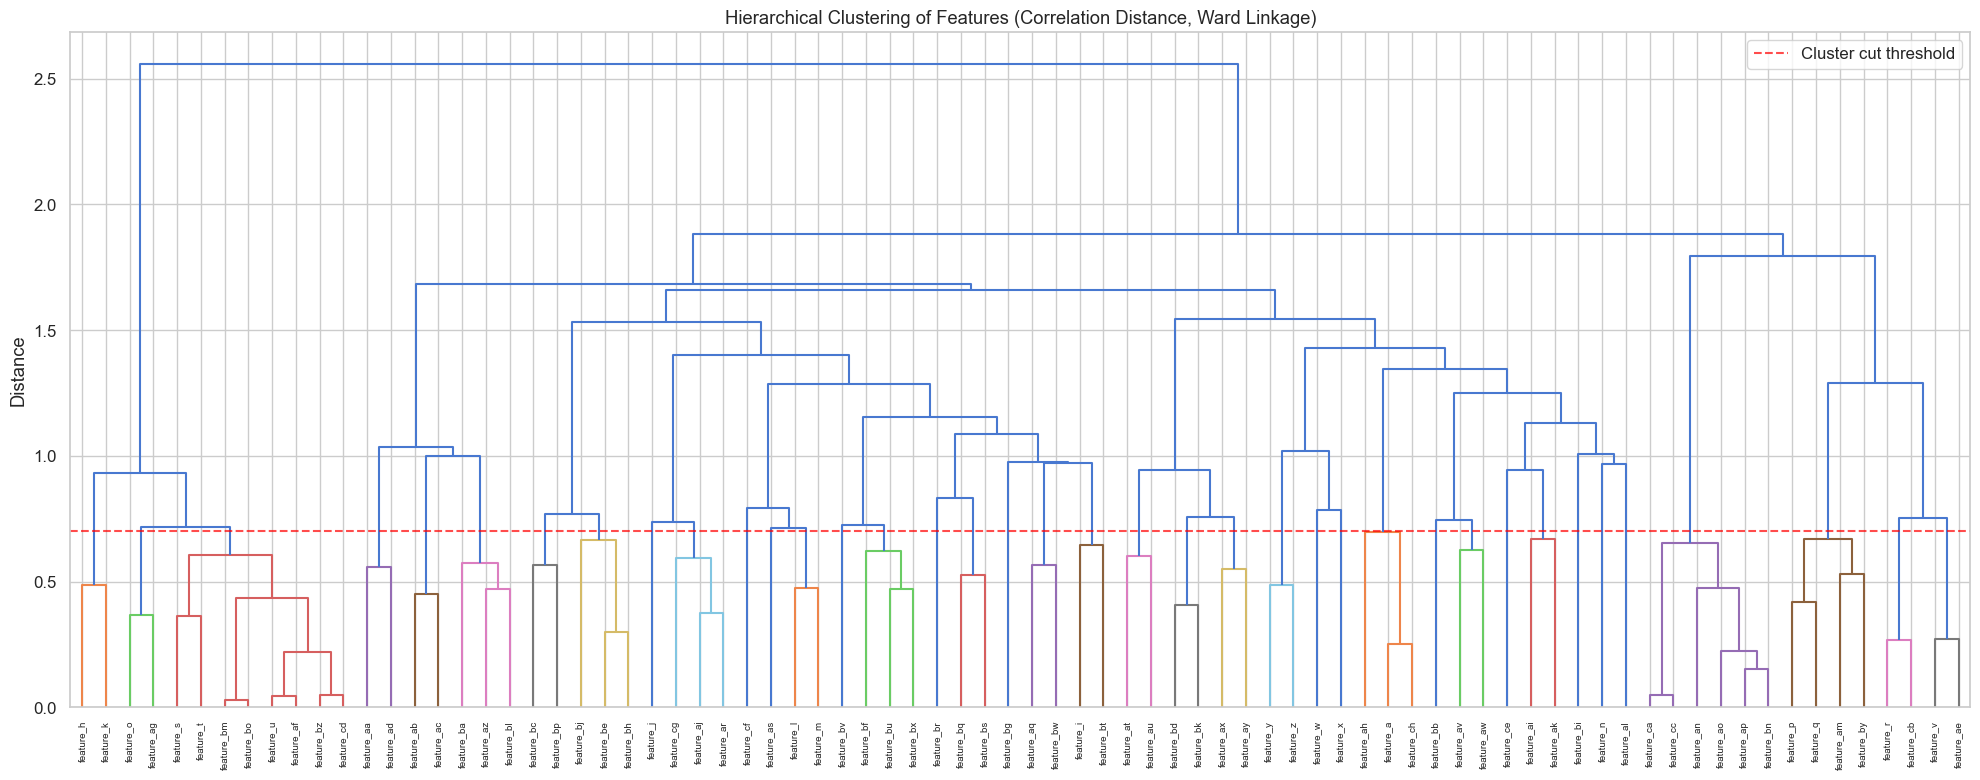

Number of clusters (threshold=0.7): 38

Largest clusters:
  Cluster 3 (8 features): ['feature_s', 'feature_t', 'feature_u', 'feature_af', 'feature_bm', 'feature_bo', 'feature_bz', 'feature_cd']
  Cluster 35 (6 features): ['feature_an', 'feature_ao', 'feature_ap', 'feature_bn', 'feature_ca', 'feature_cc']
  Cluster 36 (4 features): ['feature_p', 'feature_q', 'feature_am', 'feature_by']
  Cluster 14 (3 features): ['feature_bf', 'feature_bu', 'feature_bx']
  Cluster 6 (3 features): ['feature_az', 'feature_ba', 'feature_bl']


In [49]:
# Compute correlation-based distance matrix
corr_sample = train[selected_feats].sample(100000, random_state=42).dropna()
corr_matrix = corr_sample.corr()
distance_matrix = 1 - corr_matrix.abs()

# Ensure symmetry and zero diagonal
np.fill_diagonal(distance_matrix.values, 0)
distance_matrix = (distance_matrix + distance_matrix.T) / 2

# Hierarchical clustering
condensed_dist = squareform(distance_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

fig, ax = plt.subplots(figsize=(20, 8))
dendrogram(linkage_matrix, labels=distance_matrix.columns.tolist(),
           leaf_rotation=90, leaf_font_size=7, ax=ax, color_threshold=0.7)
ax.set_title('Hierarchical Clustering of Features (Correlation Distance, Ward Linkage)')
ax.set_ylabel('Distance')
ax.axhline(0.7, color='red', linestyle='--', alpha=0.7, label='Cluster cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Extract clusters at a threshold
cluster_labels = fcluster(linkage_matrix, t=0.7, criterion='distance')
cluster_df = pd.DataFrame({'feature': distance_matrix.columns, 'cluster': cluster_labels})
cluster_counts = cluster_df.groupby('cluster').size().sort_values(ascending=False)

print(f'Number of clusters (threshold=0.7): {cluster_counts.shape[0]}')
print(f'\nLargest clusters:')
for cid in cluster_counts.head(5).index:
    members = cluster_df[cluster_df['cluster'] == cid]['feature'].tolist()
    print(f'  Cluster {cid} ({len(members)} features): {members[:8]}{"..." if len(members) > 8 else ""}')

**Interpretation:**
- The dendrogram reveals natural groupings of features based on correlation similarity.
- Features that merge at low distance (close together in the tree) are near-redundant — keeping all of them adds complexity without new information.
- The previously identified pairs (bm↔bo, u↔af, bz↔cd) should appear as tightly linked leaves.

**Implication:** For dimensionality reduction, select one representative feature per cluster (e.g., the one with highest MI with target). This gives a principled way to reduce from ~85 features to ~20–30 without arbitrary thresholding.

---
## 12. Per-Horizon & Per-Code Deep Dive

*Domain-specific analysis — understanding how feature-target relationships
vary across the hierarchical structure.*

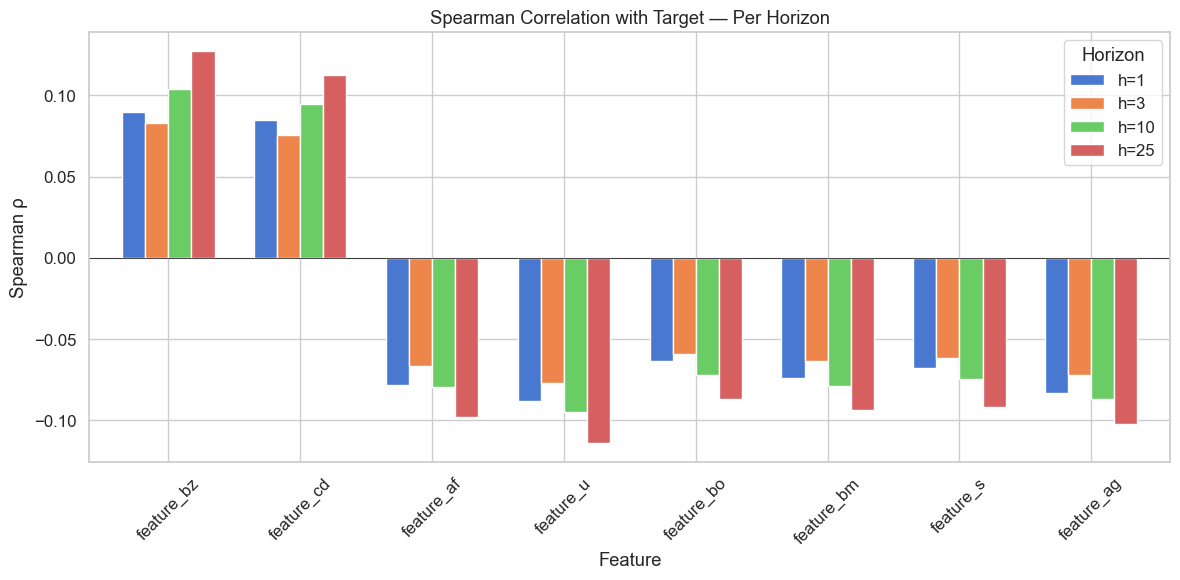

In [52]:
# Feature-target Spearman correlation per horizon
top_features = ['feature_bz', 'feature_cd', 'feature_af', 'feature_u',
                'feature_bo', 'feature_bm', 'feature_s', 'feature_ag']

horizon_corr = {}
for h in sorted(train['horizon'].unique()):
    h_data = train[train['horizon'] == h][top_features + ['y_target']].sample(
        min(100000, (train['horizon'] == h).sum()), random_state=42
    )
    horizon_corr[f'h={h}'] = h_data.corr(method='spearman')['y_target'].drop('y_target')

hc_df = pd.DataFrame(horizon_corr)

fig, ax = plt.subplots(figsize=(12, 6))
hc_df.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Spearman Correlation with Target — Per Horizon')
ax.set_ylabel('Spearman ρ')
ax.set_xlabel('Feature')
ax.axhline(0, color='black', linewidth=0.5)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Horizon')
plt.tight_layout()
plt.show()

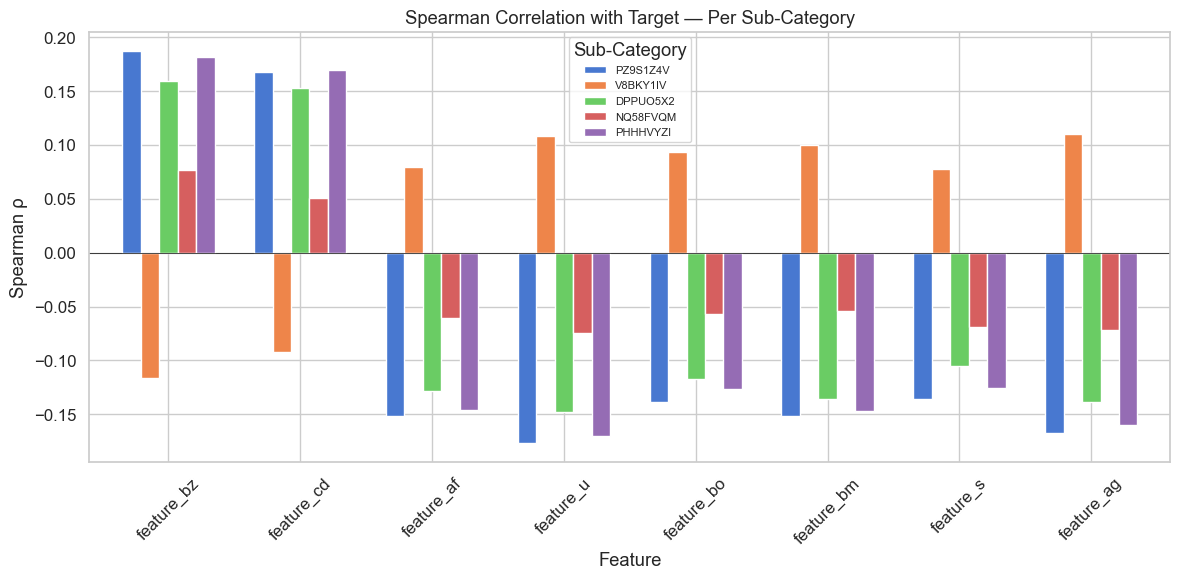

In [53]:
# Feature-target correlation per sub_category
subcat_corr = {}
for sc in train['sub_category'].unique():
    sc_data = train[train['sub_category'] == sc][top_features + ['y_target']].sample(
        min(100000, (train['sub_category'] == sc).sum()), random_state=42
    )
    subcat_corr[sc] = sc_data.corr(method='spearman')['y_target'].drop('y_target')

sc_df = pd.DataFrame(subcat_corr)

fig, ax = plt.subplots(figsize=(12, 6))
sc_df.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Spearman Correlation with Target — Per Sub-Category')
ax.set_ylabel('Spearman ρ')
ax.set_xlabel('Feature')
ax.axhline(0, color='black', linewidth=0.5)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Sub-Category', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Per-horizon:** Feature-target correlations may differ substantially across horizons. A feature highly correlated at h=1 may be irrelevant at h=25 (and vice versa). This validates the strategy of training separate per-horizon models.
- **Per-sub-category:** Different sub-categories represent different return regimes. Features like `feature_bz` may be predictive for one sub-category but not another.

**Implication:** Consider interaction features (feature × horizon, feature × sub_category) or hierarchical/multi-task modelling to exploit these structured differences.

---
## 13. Train–Test Feature Distribution Comparison (KS Test)

*Formal statistical test for distribution shift between train and test.*

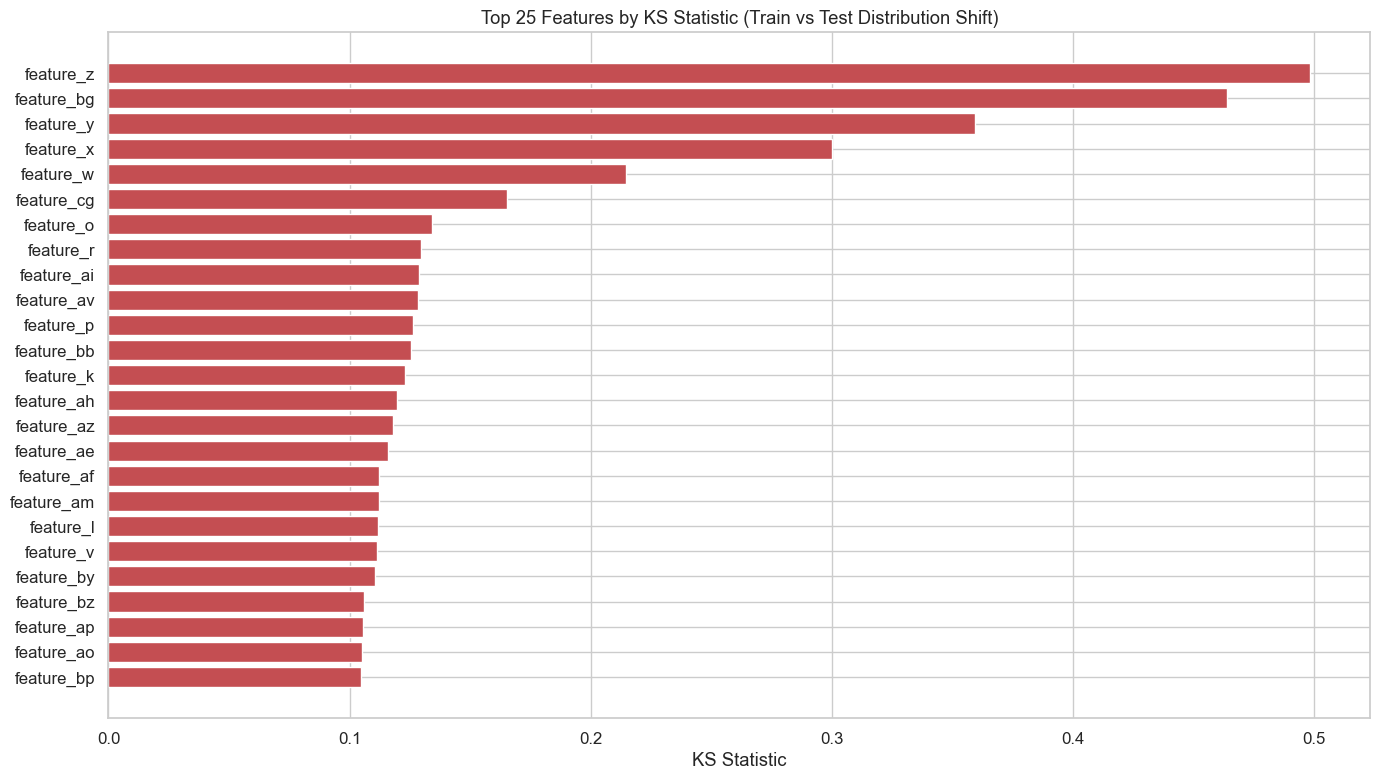

Features with significant shift (p < 0.001): 79 / 86


In [56]:
# KS test on each feature
ks_results = []
for c in feature_cols:
    train_vals = train[c].dropna().sample(min(50000, train[c].dropna().shape[0]), random_state=42)
    test_vals  = test[c].dropna().sample(min(50000, test[c].dropna().shape[0]), random_state=42)
    ks_stat, ks_p = stats.ks_2samp(train_vals, test_vals)
    ks_results.append({'feature': c, 'ks_stat': ks_stat, 'ks_pvalue': ks_p})

ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_ks = ks_df.head(25)
colors = ['#C44E52' if p < 0.001 else '#4C72B0' for p in top_ks['ks_pvalue']]
ax.barh(range(len(top_ks)), top_ks['ks_stat'], color=colors)
ax.set_yticks(range(len(top_ks)))
ax.set_yticklabels(top_ks['feature'])
ax.invert_yaxis()
ax.set_xlabel('KS Statistic')
ax.set_title('Top 25 Features by KS Statistic (Train vs Test Distribution Shift)')
plt.tight_layout()
plt.show()

n_sig = (ks_df['ks_pvalue'] < 0.001).sum()
print(f'Features with significant shift (p < 0.001): {n_sig} / {len(feature_cols)}')

**Interpretation:**
- The Kolmogorov-Smirnov (KS) test quantifies the maximum distance between the train and test CDFs.
- Features with high KS statistics (shown in red) have significantly different distributions in train vs test.
- Given the large sample sizes, even small differences will be "statistically significant" — the KS statistic magnitude matters more than the p-value.

**Implication:** Features with the highest KS statistics are the most "shifted". If these features have high importance in the model, predictions may degrade. Use adversarial validation or domain adaptation techniques to mitigate.

---
## 14. Summary: Consolidated Feature Intelligence

*Bring together Pearson, Spearman, MI, KS shift, and missing % into a single
feature ranking table.*

In [59]:
# Build consolidated ranking table
ranking = pd.DataFrame(index=feature_cols)

ranking['pearson_abs']  = pearson_corr
ranking['spearman_abs'] = spearman_corr
ranking['mutual_info']  = mi_series
ranking['ks_stat']      = ks_df.set_index('feature')['ks_stat']
ranking['missing_pct']  = train[feature_cols].isnull().mean() * 100

# Rank each metric (lower rank = better for corr/MI, worse for KS)
ranking['rank_pearson']  = ranking['pearson_abs'].rank(ascending=False)
ranking['rank_spearman'] = ranking['spearman_abs'].rank(ascending=False)
ranking['rank_mi']       = ranking['mutual_info'].rank(ascending=False)
ranking['rank_ks']       = ranking['ks_stat'].rank(ascending=True)  # lower KS = less shift = better

# Composite score (average rank — lower is better)
ranking['composite_rank'] = ranking[['rank_pearson','rank_spearman','rank_mi','rank_ks']].mean(axis=1)
ranking = ranking.sort_values('composite_rank')

print('=== Top 20 Features (Composite Ranking) ===')
display(ranking[['pearson_abs','spearman_abs','mutual_info','ks_stat','missing_pct','composite_rank']].head(20))

print('\n=== Bottom 10 Features (Likely Noise / Risky) ===')
display(ranking[['pearson_abs','spearman_abs','mutual_info','ks_stat','missing_pct','composite_rank']].tail(10))

=== Top 20 Features (Composite Ranking) ===


,pearson_abs,spearman_abs,mutual_info,ks_stat,missing_pct,composite_rank
feature_u,0.0660,0.0955,0.5636,0.0880,0.1334,15.0000
feature_bz,0.0758,0.1044,0.5079,0.1058,2.8426,19.2500
feature_bn,0.0156,0.0849,0.4886,0.0709,0.0000,20.7500
feature_am,0.0308,0.0955,0.6478,0.1122,0.0000,21.2500
feature_cd,0.0730,0.0948,0.4241,0.1012,7.4964,21.7500
feature_cc,0.0203,0.0917,0.4006,0.0755,0.0494,22.2500
feature_bm,0.0492,0.0797,0.4486,0.0845,0.0000,22.5000
feature_bw,0.0187,0.0315,0.5522,0.0518,0.0000,22.5000
feature_bo,0.0525,0.0718,0.4062,0.0588,0.0000,22.7500
feature_by,0.0240,0.1018,0.4784,0.1106,11.0192,24.5000



=== Bottom 10 Features (Likely Noise / Risky) ===


,pearson_abs,spearman_abs,mutual_info,ks_stat,missing_pct,composite_rank
feature_e,0.0012,0.0017,0.0043,0.0057,0.0000,61.2500
feature_aa,0.0039,0.0146,0.0898,0.1016,0.1153,62.0000
feature_f,0.0015,0.0021,0.0000,0.0092,0.0000,62.6250
feature_w,0.0015,0.0041,0.4604,0.2146,0.1159,63.0000
feature_g,0.0007,0.0000,0.0008,0.0042,0.0000,63.5000
feature_z,0.0059,0.0060,0.2811,0.4986,0.1159,64.0000
feature_x,0.0034,0.0004,0.3767,0.3002,0.1159,66.7500
feature_ay,0.0006,0.0092,0.0491,0.0845,8.5420,67.5000
feature_ax,0.0004,0.0078,0.0474,0.0870,0.7196,68.7500
feature_cg,0.0018,0.0013,0.3164,0.1653,0.7428,69.7500


**Interpretation:** This table is the single most actionable output of the advanced EDA. Features at the top have:
- High linear and nonlinear correlation with target
- High mutual information
- Low distribution shift (stable between train and test)

Features at the bottom are either noise (low signal) or risky (high shift). They should be the first candidates for removal.

**Preprocessing Action:** Use the top-N features from this composite ranking as the initial feature set. Fine-tune N via cross-validation with permutation importance.

---
## 15. Key Takeaways for Modelling

| Finding | Source Section | Action |
|---------|--------------|--------|
| Universe grows over time (entity count increases) | §2 | Weight recent data more; time-aware CV |
| Features `o`, `p`, `s` show clear upward drift | §3 | Use rolling normalisation or de-trending |
| Target is extremely non-Gaussian (Shapiro rejected, kurtosis=290) | §4 | Use Huber/MAE loss; clip extreme target values |
| Significant positive autocorrelation in target at short lags | §5 | Lagged target features (with care for leakage) |
| Correlation structure is non-stationary (Frobenius norm fluctuates) | §6 | Time-adaptive feature selection; recency weighting |
| ~20-30 PCA components capture 95% variance of 85+ features | §7 | Use PCA as preprocessing for linear models |
| Several features show clear non-stationarity in mean and std | §8 | Per-window normalisation; drop unstable features |
| Spearman ≠ Pearson for some features (nonlinear signal) | §9 | Tree models preferred; consider nonlinear transforms |
| MI identifies features with complex dependencies | §10 | Combine MI + Spearman + Pearson for feature selection |
| Feature clustering reveals ~20-30 natural groups | §11 | Select one per cluster to reduce redundancy |
| Feature-target correlations vary by horizon and sub_category | §12 | Per-horizon models or horizon-aware features |
| KS test confirms significant train-test shift in many features | §13 | Monitor shifted features; adversarial validation |
| Composite feature ranking provides actionable top-N list | §14 | Use as baseline feature set |


In [70]:
print('Advanced EDA complete.')
print(f'  Effective dimensionality (95% PCA): ~{n_95} components out of {len(feature_cols)} features')
print(f'  Features with significant train-test shift: {n_sig}')
print(f'  Feature clusters (threshold=0.7): {cluster_counts.shape[0]}')

Advanced EDA complete.
  Effective dimensionality (95% PCA): ~1 components out of 86 features
  Features with significant train-test shift: 79
  Feature clusters (threshold=0.7): 38
